# Прогнозирование покупки по данным пользовательской сессии

**Датасет:** Online Shoppers Purchasing Intention Dataset.

## Задача

Построить модель бинарной классификации, которая по данным пользовательской сессии прогнозирует, завершится ли она покупкой.

Целевая переменная `Revenue`:
- `True` - сессия завершилась покупкой;
- `False` - покупка не совершена.

## Описание данных

Датасет содержит 12 330 пользовательских сессий и 17 признаков. Одна строка соответствует одной сессии.

### Признаки

- `Administrative`, `Administrative_Duration` - количество посещённых административных страниц и время на них.
- `Informational`, `Informational_Duration` - количество информационных страниц и время на них.
- `ProductRelated`, `ProductRelated_Duration` - количество товарных страниц и время на них.
- `BounceRates` - показатель отказов.
- `ExitRates` - показатель выходов.
- `PageValues` - ценность посещённых страниц по данным веб-аналитики.
- `SpecialDay` - близость даты сессии к особому дню.
- `Month` - месяц сессии.
- `OperatingSystems` - операционная система.
- `Browser` - браузер.
- `Region` - регион.
- `TrafficType` - источник трафика.
- `VisitorType` - тип посетителя.
- `Weekend` - произошла ли сессия в выходной день.

`Month`, `OperatingSystems`, `Browser`, `Region`, `TrafficType`, `VisitorType` и `Weekend` рассматриваются как категориальные признаки.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy.stats import mannwhitneyu, spearmanr
from sklearn.base import BaseEstimator, clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    FunctionTransformer,
    OneHotEncoder,
    StandardScaler,
)
from sklearn.tree import DecisionTreeClassifier
from statsmodels.stats.proportion import proportions_ztest

## Загрузка данных

In [77]:
DATA_URL = (
    "https://raw.githubusercontent.com/"
    "helenhunt-alt/online-shoppers-purchase-prediction/"
    "main/data/online_shoppers_intention.csv"
)

df = pd.read_csv(DATA_URL)

## Первичный осмотр

In [3]:
df.shape

(12330, 18)

In [4]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [6]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


In [7]:
df.describe(include="object")

,Month,VisitorType
count,12330,12330
unique,10,3
top,May,Returning_Visitor
freq,3364,10551


In [8]:
df.isna().sum()

,0
Administrative,0
Administrative_Duration,0
Informational,0
Informational_Duration,0
ProductRelated,0
ProductRelated_Duration,0
BounceRates,0
ExitRates,0
PageValues,0
SpecialDay,0


In [9]:
df.duplicated().sum()

np.int64(125)

In [10]:
df.nunique()

,0
Administrative,27
Administrative_Duration,3335
Informational,17
Informational_Duration,1258
ProductRelated,311
ProductRelated_Duration,9551
BounceRates,1872
ExitRates,4777
PageValues,2704
SpecialDay,6


### Вывод по первичному осмотру

Датасет содержит 12 330 строк и 18 столбцов. Пропуски отсутствуют.

`OperatingSystems`, `Browser`, `Region` и `TrafficType` записаны числами, но по смыслу являются категориальными признаками.

Большинство числовых признаков имеет правостороннюю асимметрию и редкие крупные значения. В нескольких признаках также преобладают нули. Эти особенности будут подробнее рассмотрены в EDA.

Обнаружено 125 полных дубликатов. Перед удалением необходимо проверить их состав и связь с целевой переменной.

## Гипотезы о данных

1. В сессиях с покупкой медианное количество просмотренных товарных страниц выше, чем в сессиях без покупки.

2. В сессиях с покупкой медианная длительность просмотра товарных страниц выше, чем в сессиях без покупки.

3. В сессиях с покупкой медианный показатель отказов ниже, чем в сессиях без покупки.

4. Доля сессий с посещением административных страниц выше среди сессий с покупкой.

5. Доля покупок среди вернувшихся посетителей выше, чем среди новых.

6. Доля покупок увеличивается с ростом значения `SpecialDay`.

## Исследовательский анализ данных

### Проверка качества данных

#### Полные дубликаты



In [11]:
duplicate_rows = df[df.duplicated(keep=False)]

print(f"Всего строк, входящих в группы дубликатов: {len(duplicate_rows)}")
duplicate_rows.head(20)

Всего строк, входящих в группы дубликатов: 201


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
85,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,1,1,1,3,Returning_Visitor,False,False
132,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,3,2,3,3,Returning_Visitor,False,False
158,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,1,1,1,3,Returning_Visitor,False,False
159,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,3,2,3,3,Returning_Visitor,False,False
178,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,3,2,3,3,Returning_Visitor,False,False
252,0,0.0,0,0.0,2,0.0,0.2,0.2,0.0,0.0,Mar,1,1,1,1,Returning_Visitor,False,False
286,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Mar,2,2,1,1,Returning_Visitor,False,False
293,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Mar,1,1,1,1,Returning_Visitor,True,False
298,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Mar,1,1,8,1,Returning_Visitor,False,False
330,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Mar,3,2,3,1,Returning_Visitor,False,False


In [12]:
feature_columns = df.columns.drop("Revenue").tolist()

feature_groups = (
    df.groupby(feature_columns, dropna=False)["Revenue"]
    .agg(
        session_count="size",
        unique_revenue_count="nunique",
    )
    .reset_index()
)

repeated_feature_groups = feature_groups[
    feature_groups["session_count"] > 1
]

conflicting_feature_groups = repeated_feature_groups[
    repeated_feature_groups["unique_revenue_count"] > 1
]

print(
    "Количество повторяющихся комбинаций признаков:",
    len(repeated_feature_groups),
)

print(
    "Количество комбинаций с разными значениями Revenue:",
    len(conflicting_feature_groups),
)

conflicting_feature_groups.head()

Количество повторяющихся комбинаций признаков: 76
Количество комбинаций с разными значениями Revenue: 0


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,session_count,unique_revenue_count


Обнаружено 125 полных дубликатов. Среди строк с одинаковыми признаками нет различий в `Revenue`.

Дубликаты удалены, чтобы одинаковые строки не попали одновременно в обучающую и тестовую выборки и не завысили оценку модели.

In [13]:
rows_before = len(df)

df = df.drop_duplicates().reset_index(drop=True)

rows_after = len(df)

print(f"Количество строк до удаления: {rows_before}")
print(f"Количество строк после удаления: {rows_after}")
print(f"Удалено дубликатов: {rows_before - rows_after}")

Количество строк до удаления: 12330
Количество строк после удаления: 12205
Удалено дубликатов: 125


#### Нулевые значения и согласованность признаков

In [14]:
numeric_feature_columns = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay",
]

zero_summary = pd.DataFrame(
    {
        "Количество нулей": (df[numeric_feature_columns] == 0).sum(),
        "Доля нулей, %": (
            (df[numeric_feature_columns] == 0).mean() * 100
        ).round(2),
    }
)

zero_summary = zero_summary[
    zero_summary["Количество нулей"] > 0
].sort_values("Доля нулей, %", ascending=False)

zero_summary

,Количество нулей,"Доля нулей, %"
SpecialDay,10956,89.77
Informational_Duration,9800,80.29
Informational,9574,78.44
PageValues,9475,77.63
Administrative_Duration,5778,47.34
Administrative,5643,46.24
BounceRates,5518,45.21
ProductRelated_Duration,630,5.16
ExitRates,76,0.62
ProductRelated,38,0.31


Нулевые значения имеют содержательный смысл и не считаются пропусками.

Особенно часто нули встречаются в `SpecialDay`, признаках информационных страниц и `PageValues`. Отдельно проверим согласованность количества посещённых страниц и длительности просмотра.

In [15]:
page_feature_pairs = {
    "Administrative": "Administrative_Duration",
    "Informational": "Informational_Duration",
    "ProductRelated": "ProductRelated_Duration",
}

consistency_results = []

for page_count_column, duration_column in page_feature_pairs.items():
    positive_count_zero_duration = (
        (df[page_count_column] > 0) & (df[duration_column] == 0)
    ).sum()

    zero_count_positive_duration = (
        (df[page_count_column] == 0) & (df[duration_column] > 0)
    ).sum()

    consistency_results.append(
        {
            "Тип страниц": page_count_column,
            "Страницы > 0, время = 0": positive_count_zero_duration,
            "Страницы = 0, время > 0": zero_count_positive_duration,
        }
    )

page_duration_consistency = pd.DataFrame(consistency_results)
page_duration_consistency

,Тип страниц,"Страницы > 0, время = 0","Страницы = 0, время > 0"
0,Administrative,135,0
1,Informational,226,0
2,ProductRelated,592,0


Случаев с положительной длительностью при нулевом количестве страниц нет.

Обратные ситуации встречаются: 135 раз для административных, 226 - для информационных и 592 - для товарных страниц. Это может быть связано с коротким просмотром или особенностями веб-аналитики. Удалять такие наблюдения оснований нет.

### Распределение целевой переменной

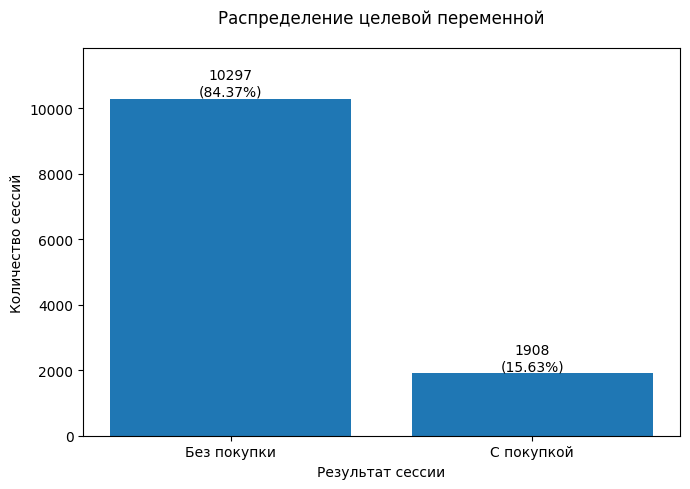

In [16]:
revenue_counts = df["Revenue"].value_counts().sort_index()
revenue_shares = (
    df["Revenue"].value_counts(normalize=True).sort_index() * 100
)

revenue_labels = ["Без покупки", "С покупкой"]

figure, axes = plt.subplots(figsize=(7, 5))

bars = axes.bar(
    revenue_labels,
    revenue_counts.values,
)

axes.set_title(
    "Распределение целевой переменной",
    pad=18,
)
axes.set_xlabel("Результат сессии")
axes.set_ylabel("Количество сессий")
axes.set_ylim(0, revenue_counts.max() * 1.15)

for bar, count, share in zip(
    bars,
    revenue_counts.values,
    revenue_shares.values,
):
    axes.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count}\n({share:.2f}%)",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

Покупкой завершились 15,63% сессий, без покупки — 84,37%. В данных есть дисбаланс классов.

Поэтому accuracy будет использоваться только как дополнительная метрика. Основной метрикой сравнения моделей станет PR-AUC.

### Распределения числовых признаков

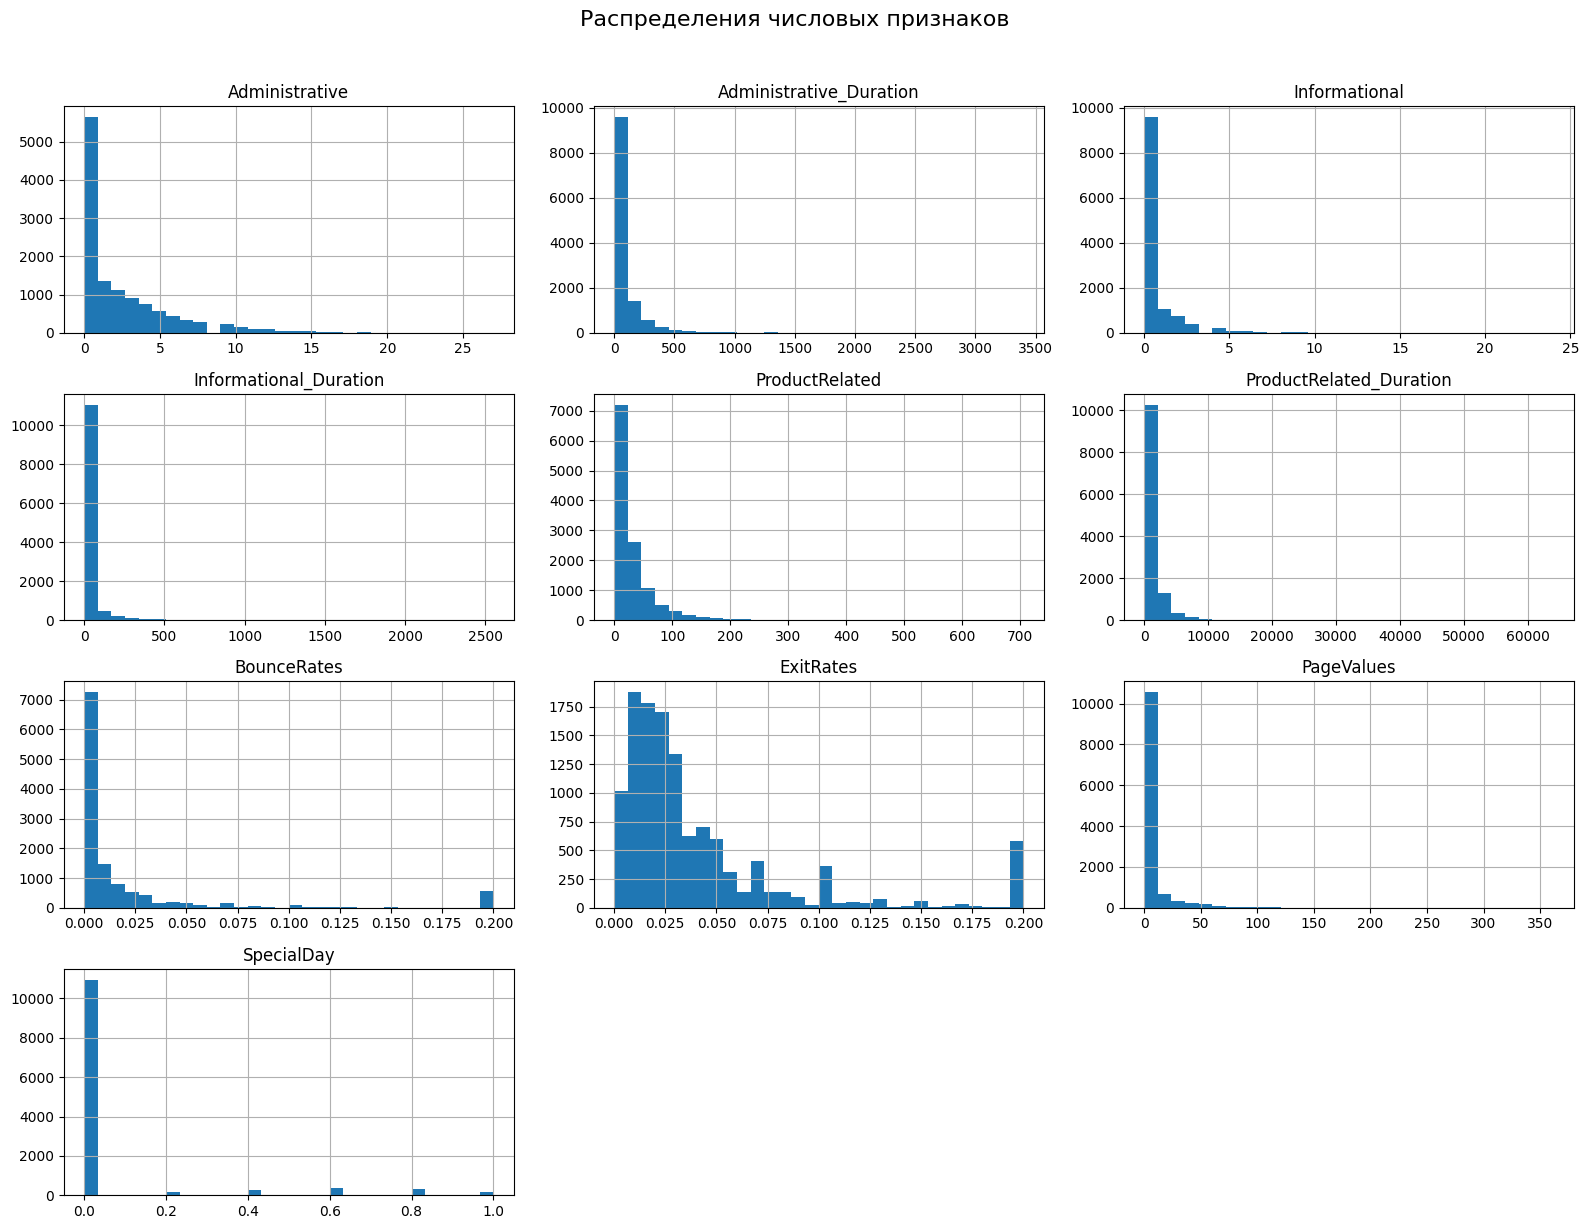

In [17]:
axes = df[numeric_feature_columns].hist(
    bins=30,
    figsize=(16, 12),
    layout=(4, 3),
)

plt.suptitle(
    "Распределения числовых признаков",
    fontsize=16,
    y=1.02,
)
plt.tight_layout()
plt.show()

Большинство числовых признаков имеет правостороннюю асимметрию и длинные правые хвосты. В части признаков также преобладают нули.

По гистограммам нельзя определить, являются ли крупные значения ошибками или редкими реальными сессиями. Поэтому рассмотрим их отдельно.

### Анализ экстремальных значений

#### Верхние перцентили и потенциальные выбросы

In [18]:
outlier_feature_columns = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "PageValues",
]

outlier_summary = []

for column in outlier_feature_columns:
    first_quartile = df[column].quantile(0.25)
    third_quartile = df[column].quantile(0.75)
    interquartile_range = third_quartile - first_quartile
    upper_iqr_boundary = third_quartile + 1.5 * interquartile_range

    potential_outlier_mask = df[column] > upper_iqr_boundary

    outlier_summary.append(
        {
            "Признак": column,
            "95-й перцентиль": df[column].quantile(0.95),
            "99-й перцентиль": df[column].quantile(0.99),
            "99,5-й перцентиль": df[column].quantile(0.995),
            "Максимум": df[column].max(),
            "Верхняя граница IQR": upper_iqr_boundary,
            "Количество выше границы": potential_outlier_mask.sum(),
            "Доля выше границы, %": (
                potential_outlier_mask.mean() * 100
            ),
        }
    )

outlier_summary_df = pd.DataFrame(outlier_summary)

outlier_summary_df.round(2)

,Признак,95-й перцентиль,99-й перцентиль,"99,5-й перцентиль",Максимум,Верхняя граница IQR,Количество выше границы,"Доля выше границы, %"
0,Administrative,9.00,14.00,16.00,27.00,10.00,404,3.31
1,Administrative_Duration,352.21,838.70,1178.47,3398.75,236.75,1149,9.41
2,Informational,3.00,6.00,7.00,24.00,0.00,2631,21.56
3,Informational_Duration,199.00,722.38,1005.39,2549.38,0.00,2405,19.71
4,ProductRelated,110.00,221.00,281.98,705.00,83.00,1007,8.25
5,ProductRelated_Duration,4312.96,8704.27,11246.03,63973.52,3403.39,951,7.79
6,PageValues,38.30,86.11,111.24,361.76,0.00,2730,22.37


#### Исследование экстремальных наблюдений

In [19]:
extreme_session_columns = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "Revenue",
]

for page_count_column, duration_column in page_feature_pairs.items():
    print(f"\nНаибольшие значения {duration_column}:")

    display(
        df.nlargest(5, duration_column)[extreme_session_columns]
    )


Наибольшие значения Administrative_Duration:


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,Revenue
7983,5,3398.750000,6,2549.375000,449,63973.522230,0.000764,0.027701,0.000000,False
5691,7,2720.500000,3,353.400000,68,5943.547619,0.032237,0.038623,0.000000,False
9149,15,2657.318056,13,1949.166667,343,29970.465970,0.005316,0.028971,0.000000,False
5074,17,2629.253968,24,2050.433333,705,43171.233380,0.004851,0.015431,0.763829,False
6080,10,2407.423810,3,434.300000,486,23050.104140,0.000324,0.011249,0.000000,False



Наибольшие значения Informational_Duration:


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,Revenue
7983,5,3398.750000,6,2549.375000,449,63973.522230,0.000764,0.027701,0.000000,False
10201,4,367.000000,5,2256.916667,74,8981.580128,0.002989,0.043302,0.000000,False
5935,8,116.972222,9,2252.033333,19,1135.880556,0.009677,0.011842,0.000000,False
5427,3,28.800000,5,2195.300000,21,378.400000,0.029630,0.030864,0.000000,False
11359,8,145.100000,6,2166.500000,14,1805.425000,0.000000,0.031138,10.900234,False



Наибольшие значения ProductRelated_Duration:


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,Revenue
7983,5,3398.750000,6,2549.375000,449,63973.52223,0.000764,0.027701,0.000000,False
5074,17,2629.253968,24,2050.433333,705,43171.23338,0.004851,0.015431,0.763829,False
9149,15,2657.318056,13,1949.166667,343,29970.46597,0.005316,0.028971,0.000000,False
8695,20,1307.675000,3,132.666667,517,27009.85943,0.004385,0.014594,8.403164,True
8220,27,853.735949,2,126.500000,584,24844.15620,0.002099,0.009347,4.511100,False


#### Средняя длительность на одну страницу

In [20]:
duration_per_page = pd.DataFrame(index=df.index)

for page_count_column, duration_column in page_feature_pairs.items():
    average_duration_column = f"{page_count_column}_Duration_Per_Page"
    positive_page_count_mask = df[page_count_column] > 0

    duration_per_page.loc[
        positive_page_count_mask,
        average_duration_column,
    ] = (
        df.loc[positive_page_count_mask, duration_column]
        / df.loc[positive_page_count_mask, page_count_column]
    )

for average_duration_column in duration_per_page.columns:
    print(f"\nНаибольшие значения {average_duration_column}:")

    largest_indices = duration_per_page[
        average_duration_column
    ].nlargest(5).index

    display(
        pd.concat(
            [
                df.loc[largest_indices, extreme_session_columns],
                duration_per_page.loc[
                    largest_indices,
                    [average_duration_column],
                ],
            ],
            axis=1,
        )
    )


Наибольшие значения Administrative_Duration_Per_Page:


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,Revenue,Administrative_Duration_Per_Page
5857,1,1566.6,0,0.0,34,2256.749540,0.000000,0.000250,0.000000,False,1566.60
221,1,993.0,0,0.0,28,1529.304670,0.001481,0.009150,0.000000,False,993.00
2395,2,1687.5,0,0.0,29,3098.033333,0.000000,0.025806,0.000000,False,843.75
9539,2,1668.5,4,35.0,18,1372.975000,0.000000,0.017391,41.646259,True,834.25
1949,1,702.0,0,0.0,38,2193.150794,0.012281,0.015614,9.092772,True,702.00



Наибольшие значения Informational_Duration_Per_Page:


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,Revenue,Informational_Duration_Per_Page
4189,3,270.0,1,1778.0,362,13259.293960,0.002883,0.008838,0.0,False,1778.0
9423,0,0.0,1,1729.0,19,1401.083333,0.020000,0.050000,0.0,False,1729.0
11104,3,34.0,1,1530.0,97,3989.485553,0.002000,0.012202,0.0,False,1530.0
529,0,0.0,1,1411.0,1,1411.000000,0.000000,0.100000,0.0,False,1411.0
240,0,0.0,1,1220.0,28,2389.333333,0.016667,0.030833,0.0,False,1220.0



Наибольшие значения ProductRelated_Duration_Per_Page:


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,Revenue,ProductRelated_Duration_Per_Page
529,0,0.0,1,1411.0,1,1411.00,0.000000,0.100000,0.0,False,1411.000000
4512,0,0.0,0,0.0,1,1364.00,0.000000,0.100000,0.0,False,1364.000000
6248,0,0.0,0,0.0,1,1195.80,0.000000,0.000000,0.0,False,1195.800000
11468,0,0.0,0,0.0,2,1787.50,0.100000,0.150000,0.0,False,893.750000
8373,0,0.0,0,0.0,3,2251.28,0.095833,0.137427,0.0,False,750.426667


Правило IQR здесь ненадёжно: для признаков с большим количеством нулей оно считает выбросами почти все положительные значения, а для асимметричных распределений отмечает слишком много наблюдений.

Проверка крупнейших значений не выявила явных ошибок. Встречаются сессии со средней длительностью просмотра страницы до 20–30 минут, но это может быть связано с паузами, открытыми вкладками или особенностями сбора данных.

Экстремальные значения не удаляются. Влияние логарифмического преобразования проверим отдельно с помощью кросс-валидации.

### Анализ категориальных признаков

#### Тип посетителя

In [21]:
visitor_type_summary = pd.DataFrame(
    {
        "Количество сессий": df["VisitorType"].value_counts(),
        "Доля сессий, %": (
            df["VisitorType"].value_counts(normalize=True) * 100
        ).round(2),
    }
)

visitor_type_summary

,Количество сессий,"Доля сессий, %"
VisitorType,,
Returning_Visitor,10431,85.46
New_Visitor,1693,13.87
Other,81,0.66


Вернувшиеся посетители составляют 85,46% сессий, новые - 13,87%. На категорию `Other` приходится только 0,66%, поэтому выводы по ней могут быть нестабильными.

#### Месяцы и выходные дни

In [22]:
month_order = [
    "Jan",
    "Feb",
    "Mar",
    "Apr",
    "May",
    "June",
    "Jul",
    "Aug",
    "Sep",
    "Oct",
    "Nov",
    "Dec",
]

observed_month_order = [
    month
    for month in month_order
    if month in df["Month"].unique()
]

month_summary = pd.DataFrame(
    {
        "Количество сессий": (
            df["Month"]
            .value_counts()
            .reindex(observed_month_order)
        ),
        "Доля сессий, %": (
            df["Month"]
            .value_counts(normalize=True)
            .reindex(observed_month_order)
            * 100
        ).round(2),
    }
)

weekend_summary = pd.DataFrame(
    {
        "Количество сессий": (
            df["Weekend"]
            .value_counts()
            .sort_index()
        ),
        "Доля сессий, %": (
            df["Weekend"]
            .value_counts(normalize=True)
            .sort_index()
            * 100
        ).round(2),
    }
)

weekend_summary.index = weekend_summary.index.map(
    {
        False: "Будний день",
        True: "Выходной",
    }
)

print("Распределение сессий по месяцам:")
display(month_summary)

print("Распределение сессий по типам дней:")
display(weekend_summary)

Распределение сессий по месяцам:


,Количество сессий,"Доля сессий, %"
Month,,
Feb,181,1.48
Mar,1860,15.24
May,3329,27.28
June,285,2.34
Jul,432,3.54
Aug,433,3.55
Sep,448,3.67
Oct,549,4.50
Nov,2982,24.43


Распределение сессий по типам дней:


,Количество сессий,"Доля сессий, %"
Weekend,,
Будний день,9346,76.58
Выходной,2859,23.42


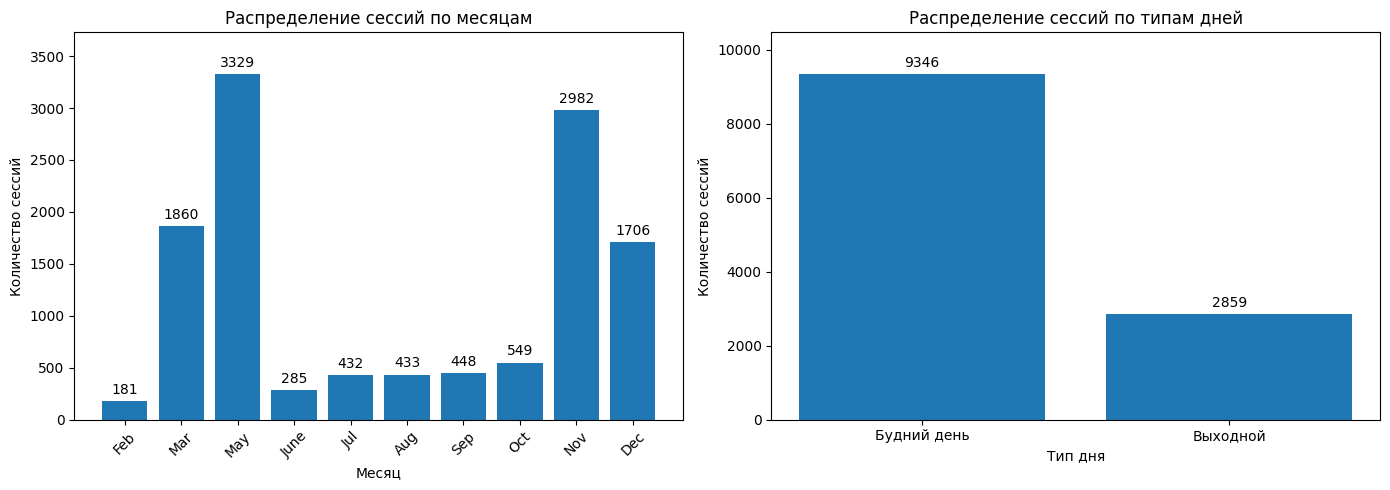

In [23]:
figure, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(14, 5),
)

month_bars = axes[0].bar(
    month_summary.index,
    month_summary["Количество сессий"],
)

axes[0].set_title("Распределение сессий по месяцам")
axes[0].set_xlabel("Месяц")
axes[0].set_ylabel("Количество сессий")
axes[0].tick_params(axis="x", rotation=45)
axes[0].bar_label(month_bars, padding=3)

weekend_bars = axes[1].bar(
    weekend_summary.index,
    weekend_summary["Количество сессий"],
)

axes[1].set_title("Распределение сессий по типам дней")
axes[1].set_xlabel("Тип дня")
axes[1].set_ylabel("Количество сессий")
axes[1].bar_label(weekend_bars, padding=3)

for axis in axes:
    axis.margins(y=0.12)

plt.tight_layout()
plt.show()

В данных отсутствуют январь и апрель. Больше половины наблюдений приходится на май и ноябрь, поэтому распределение нельзя считать полным отражением сезонности.

На будние дни приходится 76,58% сессий, на выходные - 23,42%.

#### Технические и региональные категории

In [24]:
technical_categorical_columns = [
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
]

rare_category_threshold = 0.01
category_overview = []

for column in technical_categorical_columns:
    category_counts = df[column].value_counts()
    category_shares = category_counts / len(df)

    category_overview.append(
        {
            "Признак": column,
            "Количество категорий": category_counts.size,
            "Самая частая категория": category_counts.index[0],
            "Количество в самой частой категории": category_counts.iloc[0],
            "Доля самой частой категории, %": (
                category_shares.iloc[0] * 100
            ),
            "Количество редких категорий (< 1%)": (
                category_shares < rare_category_threshold
            ).sum(),
            "Минимальная доля категории, %": (
                category_shares.min() * 100
            ),
        }
    )

category_overview_df = pd.DataFrame(category_overview)

category_overview_df.round(2)

,Признак,Количество категорий,Самая частая категория,Количество в самой частой категории,"Доля самой частой категории, %",Количество редких категорий (< 1%),"Минимальная доля категории, %"
0,OperatingSystems,8,2,6541,53.59,4,0.05
1,Browser,13,2,7883,64.59,6,0.01
2,Region,9,1,4714,38.62,0,2.61
3,TrafficType,20,2,3911,32.04,9,0.01


`OperatingSystems`, `Browser`, `Region` и `TrafficType` содержат от 8 до 20 категорий. В первых двух признаках преобладает категория `2`, а в `TrafficType` встречается много редких значений.

Несмотря на числовой формат, эти признаки являются номинальными категориями и перед обучением требуют кодирования.

### Связи между числовыми признаками

#### Корреляционная матрица

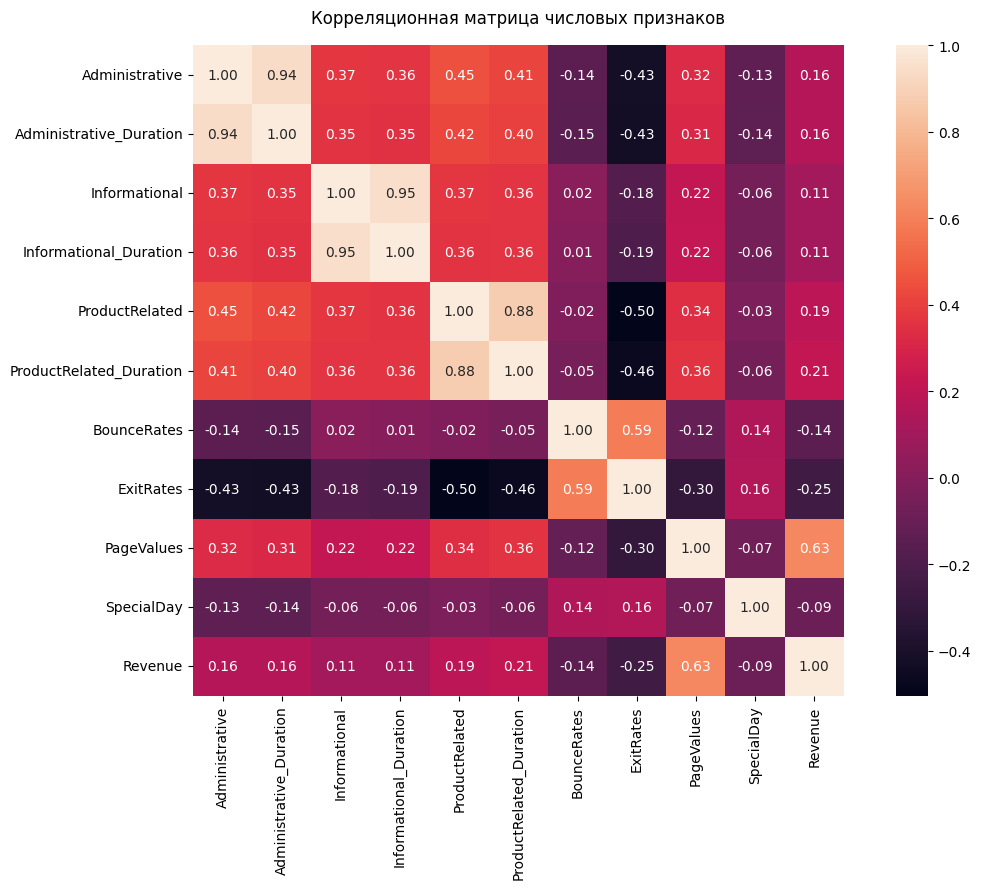

In [25]:
correlation_columns = numeric_feature_columns + ["Revenue"]

correlation_data = df[correlation_columns].copy()
correlation_data["Revenue"] = (
    correlation_data["Revenue"].astype(int)
)

spearman_correlation = correlation_data.corr(
    method="spearman"
)

plt.figure(figsize=(12, 9))

sns.heatmap(
    spearman_correlation,
    annot=True,
    fmt=".2f",
    square=True,
)

plt.title(
    "Корреляционная матрица числовых признаков",
    pad=16,
)
plt.tight_layout()
plt.show()

Количество страниц сильно связано с длительностью их просмотра: корреляции составляют от 0,88 до 0,95. Это может создавать избыточность признаков, особенно для линейных моделей.

`BounceRates` и `ExitRates` имеют корреляцию 0,59. `ExitRates` также отрицательно связан с количеством и длительностью просмотра товарных страниц.

Самая сильная связь с целевой переменной наблюдается у `PageValues` - 0,63. Его влияние дополнительно проверим сравнением моделей с этим признаком и без него.

Удалять признаки только на основании корреляций не будем.

### Проверка гипотез

#### Гипотеза 1. Количество просмотренных товарных страниц

In [26]:
product_related_summary = (
    df.groupby("Revenue")["ProductRelated"]
    .agg(
        session_count="size",
        median="median",
        mean="mean",
        first_quartile=lambda values: values.quantile(0.25),
        third_quartile=lambda values: values.quantile(0.75),
    )
)

product_related_summary.index = product_related_summary.index.map(
    {
        False: "Без покупки",
        True: "С покупкой",
    }
)

product_related_summary.round(2)

,session_count,median,mean,first_quartile,third_quartile
Revenue,,,,,
Без покупки,10297,16.0,29.05,7.0,35.0
С покупкой,1908,29.0,48.21,15.0,57.0


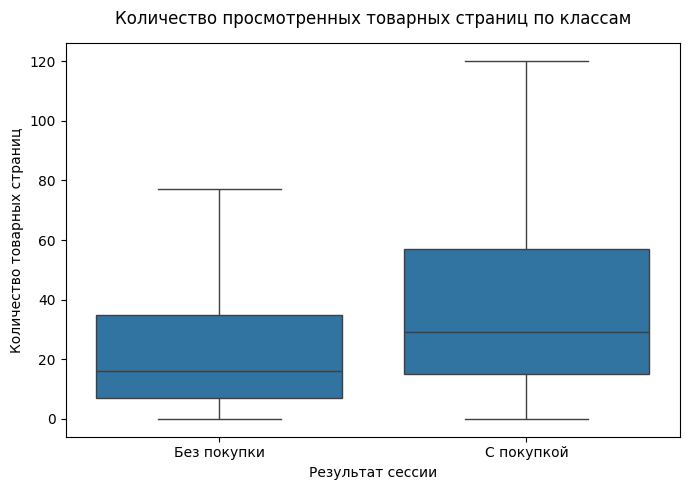

In [27]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="Revenue",
    y="ProductRelated",
    showfliers=False,
)

plt.title(
    "Количество просмотренных товарных страниц по классам",
    pad=14,
)
plt.xlabel("Результат сессии")
plt.ylabel("Количество товарных страниц")
plt.xticks(
    ticks=[0, 1],
    labels=["Без покупки", "С покупкой"],
)

plt.tight_layout()
plt.show()

In [28]:
purchased_sessions = df.loc[
    df["Revenue"],
    "ProductRelated",
]

non_purchased_sessions = df.loc[
    ~df["Revenue"],
    "ProductRelated",
]

u_statistic, p_value = mannwhitneyu(
    purchased_sessions,
    non_purchased_sessions,
    alternative="greater",
)

probability_of_superiority = (
    u_statistic
    / (len(purchased_sessions) * len(non_purchased_sessions))
)

print(f"U-статистика: {u_statistic:.0f}")
print(f"p-value: {p_value:.3e}")
print(
    "Вероятность превосходства: "
    f"{probability_of_superiority:.3f}"
)

U-статистика: 12856227
p-value: 1.847e-102
Вероятность превосходства: 0.654


Медианное количество просмотренных товарных страниц выше в сессиях с покупкой: 29 против 16.

Различие статистически значимо (`p-value < 0,001`). В 65,4% случайных пар значение выше у сессии с покупкой.

**Гипотеза 1 подтверждается.** При этом распределения пересекаются, поэтому одного этого признака недостаточно для определения покупки.

#### Гипотеза 2. Длительность просмотра товарных страниц

In [29]:
product_duration_summary = (
    df.groupby("Revenue")["ProductRelated_Duration"]
    .agg(
        session_count="size",
        median="median",
        mean="mean",
        first_quartile=lambda values: values.quantile(0.25),
        third_quartile=lambda values: values.quantile(0.75),
    )
)

product_duration_summary.index = product_duration_summary.index.map(
    {
        False: "Без покупки",
        True: "С покупкой",
    }
)

product_duration_summary.round(2)

,session_count,median,mean,first_quartile,third_quartile
Revenue,,,,,
Без покупки,10297,526.00,1082.98,159.50,1345.76
С покупкой,1908,1109.91,1876.21,541.91,2266.01


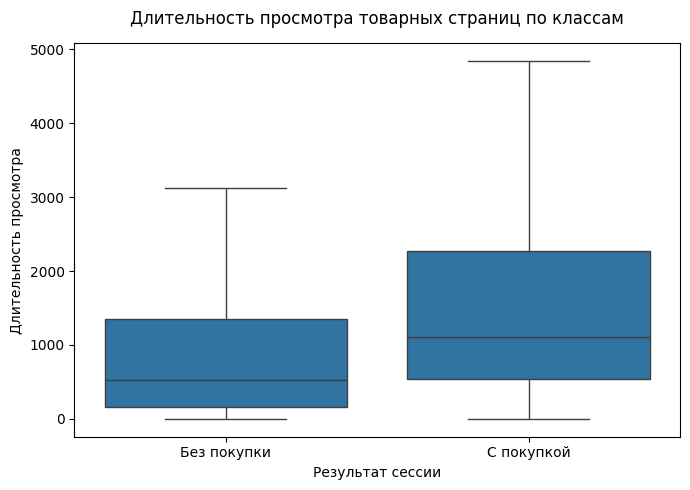

In [30]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="Revenue",
    y="ProductRelated_Duration",
    showfliers=False,
)

plt.title(
    "Длительность просмотра товарных страниц по классам",
    pad=14,
)
plt.xlabel("Результат сессии")
plt.ylabel("Длительность просмотра")
plt.xticks(
    ticks=[0, 1],
    labels=["Без покупки", "С покупкой"],
)

plt.tight_layout()
plt.show()

In [31]:
purchased_product_duration = df.loc[
    df["Revenue"],
    "ProductRelated_Duration",
]

non_purchased_product_duration = df.loc[
    ~df["Revenue"],
    "ProductRelated_Duration",
]

u_statistic, p_value = mannwhitneyu(
    purchased_product_duration,
    non_purchased_product_duration,
    alternative="greater",
)

probability_of_superiority = (
    u_statistic
    / (
        len(purchased_product_duration)
        * len(non_purchased_product_duration)
    )
)

print(f"U-статистика: {u_statistic:.0f}")
print(f"p-value: {p_value:.3e}")
print(
    "Вероятность превосходства: "
    f"{probability_of_superiority:.3f}"
)

U-статистика: 13145026
p-value: 2.092e-122
Вероятность превосходства: 0.669


Медианная длительность просмотра товарных страниц выше в сессиях с покупкой: 1109,91 против 526,00.

Различие статистически значимо (`p-value < 0,001`). В 66,9% случайных пар длительность выше у сессии с покупкой.

**Гипотеза 2 подтверждается.** Однако продолжительный просмотр не всегда заканчивается покупкой.

#### Гипотеза 3. Показатель отказов

In [32]:
bounce_rates_summary = (
    df.groupby("Revenue")["BounceRates"]
    .agg(
        session_count="size",
        median="median",
        mean="mean",
        first_quartile=lambda values: values.quantile(0.25),
        third_quartile=lambda values: values.quantile(0.75),
        zero_share=lambda values: (values == 0).mean() * 100,
    )
)

bounce_rates_summary.index = bounce_rates_summary.index.map(
    {
        False: "Без покупки",
        True: "С покупкой",
    }
)

bounce_rates_summary.round(4)

,session_count,median,mean,first_quartile,third_quartile,zero_share
Revenue,,,,,,
Без покупки,10297,0.0039,0.0232,0.0,0.0193,43.5272
С покупкой,1908,0.0000,0.0051,0.0,0.0065,54.2977


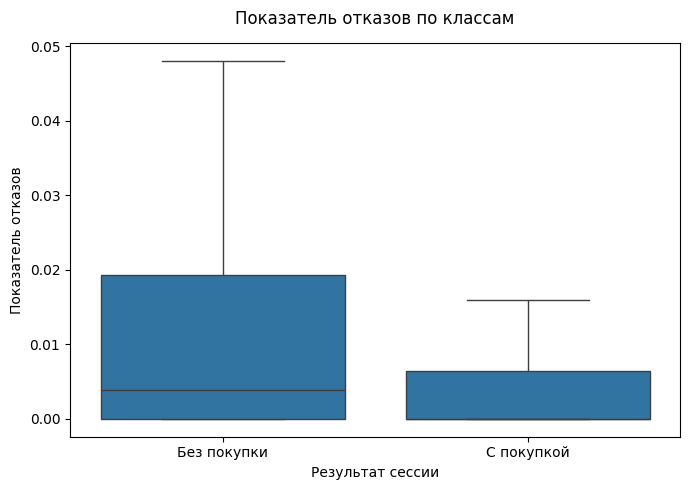

In [33]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="Revenue",
    y="BounceRates",
    showfliers=False,
)

plt.title(
    "Показатель отказов по классам",
    pad=14,
)
plt.xlabel("Результат сессии")
plt.ylabel("Показатель отказов")
plt.xticks(
    ticks=[0, 1],
    labels=["Без покупки", "С покупкой"],
)

plt.tight_layout()
plt.show()

In [34]:
purchased_bounce_rates = df.loc[
    df["Revenue"],
    "BounceRates",
]

non_purchased_bounce_rates = df.loc[
    ~df["Revenue"],
    "BounceRates",
]

u_statistic, p_value = mannwhitneyu(
    purchased_bounce_rates,
    non_purchased_bounce_rates,
    alternative="less",
)

probability_purchased_lower = 1 - (
    u_statistic
    / (
        len(purchased_bounce_rates)
        * len(non_purchased_bounce_rates)
    )
)

print(f"U-статистика: {u_statistic:.0f}")
print(f"p-value: {p_value:.3e}")
print(
    "Вероятность меньшего значения при покупке: "
    f"{probability_purchased_lower:.3f}"
)

U-статистика: 7686496
p-value: 5.300e-57
Вероятность меньшего значения при покупке: 0.609


Медианный `BounceRates` ниже в сессиях с покупкой: 0 против 0,0039. Нулевое значение встречается в 54,30% сессий с покупкой и в 43,53% сессий без неё.

Различие статистически значимо (`p-value < 0,001`). Вероятность меньшего значения в сессии с покупкой составляет 60,9%.

**Гипотеза 3 подтверждается**, но различие между группами умеренное.

#### Гипотеза 4. Посещение административных страниц

In [35]:
has_administrative = df["Administrative"] > 0

administrative_summary = (
    df.assign(has_administrative=has_administrative)
    .groupby("Revenue")["has_administrative"]
    .agg(
        session_count="size",
        sessions_with_administrative="sum",
        share_with_administrative="mean",
    )
)

administrative_summary["share_with_administrative"] *= 100

administrative_summary.index = administrative_summary.index.map(
    {
        False: "Без покупки",
        True: "С покупкой",
    }
)

administrative_summary.round(2)

,session_count,sessions_with_administrative,share_with_administrative
Revenue,,,
Без покупки,10297,5168,50.19
С покупкой,1908,1394,73.06


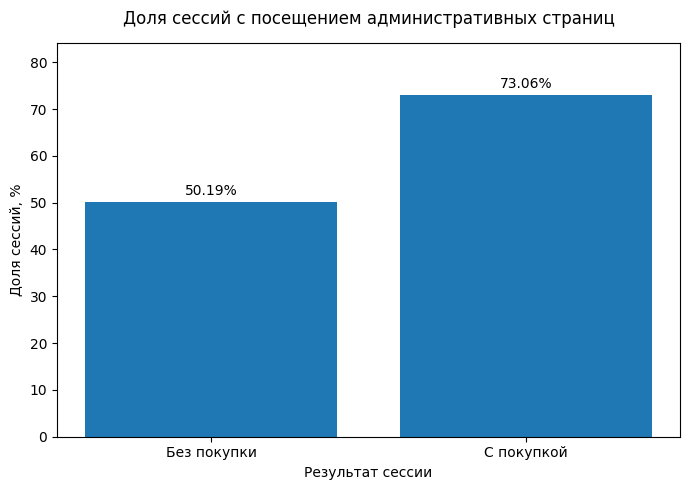

In [36]:
figure, axes = plt.subplots(figsize=(7, 5))

bars = axes.bar(
    administrative_summary.index,
    administrative_summary["share_with_administrative"],
)

axes.set_title(
    "Доля сессий с посещением административных страниц",
    pad=14,
)
axes.set_xlabel("Результат сессии")
axes.set_ylabel("Доля сессий, %")
axes.set_ylim(
    0,
    administrative_summary["share_with_administrative"].max() * 1.15,
)

axes.bar_label(
    bars,
    labels=[
        f"{share:.2f}%"
        for share in administrative_summary[
            "share_with_administrative"
        ]
    ],
    padding=3,
)

plt.tight_layout()
plt.show()

In [37]:
purchased_administrative_count = int(
    administrative_summary.loc[
        "С покупкой",
        "sessions_with_administrative",
    ]
)
purchased_session_count = int(
    administrative_summary.loc[
        "С покупкой",
        "session_count",
    ]
)

non_purchased_administrative_count = int(
    administrative_summary.loc[
        "Без покупки",
        "sessions_with_administrative",
    ]
)
non_purchased_session_count = int(
    administrative_summary.loc[
        "Без покупки",
        "session_count",
    ]
)

z_statistic, p_value = proportions_ztest(
    count=[
        purchased_administrative_count,
        non_purchased_administrative_count,
    ],
    nobs=[
        purchased_session_count,
        non_purchased_session_count,
    ],
    alternative="larger",
)

purchased_share = (
    purchased_administrative_count
    / purchased_session_count
)
non_purchased_share = (
    non_purchased_administrative_count
    / non_purchased_session_count
)

share_difference = purchased_share - non_purchased_share
relative_ratio = purchased_share / non_purchased_share

print(f"Z-статистика: {z_statistic:.3f}")
print(f"p-value: {p_value:.3e}")
print(
    "Разница долей: "
    f"{share_difference * 100:.2f} п.п."
)
print(
    "Отношение долей: "
    f"{relative_ratio:.3f}"
)

Z-статистика: 18.405
p-value: 6.000e-76
Разница долей: 22.87 п.п.
Отношение долей: 1.456


Административные страницы посещались в 73,06% сессий с покупкой и в 50,19% сессий без покупки. Разница составила 22,87 п.п.

Различие статистически значимо (`p-value < 0,001`).

**Гипотеза 4 подтверждается:** посещение административных страниц чаще встречается в сессиях с покупкой.

#### Гипотеза 5. Тип посетителя

In [38]:
visitor_purchase_summary = (
    df.groupby("VisitorType")["Revenue"]
    .agg(
        session_count="size",
        purchase_count="sum",
        purchase_rate="mean",
    )
    .sort_values("purchase_rate", ascending=False)
)

visitor_purchase_summary["purchase_rate"] *= 100

visitor_purchase_summary.round(2)

,session_count,purchase_count,purchase_rate
VisitorType,,,
New_Visitor,1693,422,24.93
Other,81,16,19.75
Returning_Visitor,10431,1470,14.09


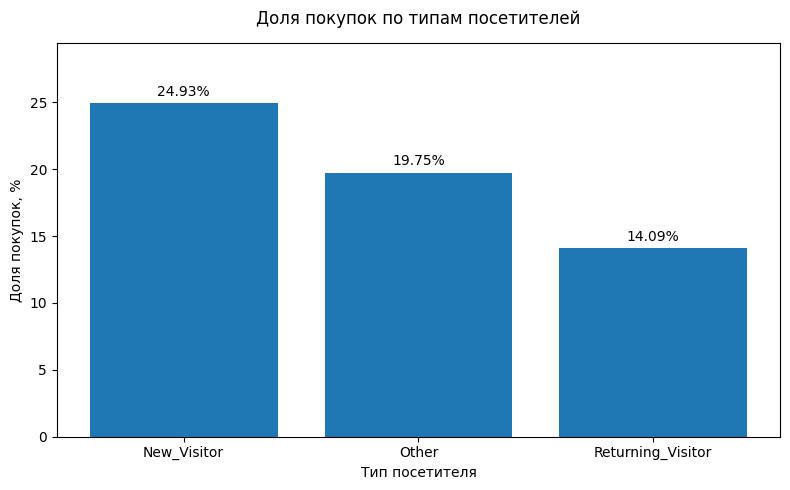

In [39]:
figure, axes = plt.subplots(figsize=(8, 5))

bars = axes.bar(
    visitor_purchase_summary.index,
    visitor_purchase_summary["purchase_rate"],
)

axes.set_title(
    "Доля покупок по типам посетителей",
    pad=14,
)
axes.set_xlabel("Тип посетителя")
axes.set_ylabel("Доля покупок, %")
axes.set_ylim(
    0,
    visitor_purchase_summary["purchase_rate"].max() * 1.18,
)

axes.bar_label(
    bars,
    labels=[
        f"{purchase_rate:.2f}%"
        for purchase_rate in visitor_purchase_summary["purchase_rate"]
    ],
    padding=3,
)

plt.tight_layout()
plt.show()

In [40]:
returning_purchase_count = int(
    visitor_purchase_summary.loc[
        "Returning_Visitor",
        "purchase_count",
    ]
)
returning_session_count = int(
    visitor_purchase_summary.loc[
        "Returning_Visitor",
        "session_count",
    ]
)

new_purchase_count = int(
    visitor_purchase_summary.loc[
        "New_Visitor",
        "purchase_count",
    ]
)
new_session_count = int(
    visitor_purchase_summary.loc[
        "New_Visitor",
        "session_count",
    ]
)

z_statistic, p_value = proportions_ztest(
    count=[
        returning_purchase_count,
        new_purchase_count,
    ],
    nobs=[
        returning_session_count,
        new_session_count,
    ],
    alternative="larger",
)

returning_purchase_rate = (
    returning_purchase_count / returning_session_count
)
new_purchase_rate = new_purchase_count / new_session_count

purchase_rate_difference = (
    returning_purchase_rate - new_purchase_rate
)

print(f"Z-статистика: {z_statistic:.3f}")
print(f"p-value: {p_value:.3e}")
print(
    "Разница долей: "
    f"{purchase_rate_difference * 100:.2f} п.п."
)

Z-статистика: -11.393
p-value: 1.000e+00
Разница долей: -10.83 п.п.


In [41]:
reverse_z_statistic, reverse_p_value = proportions_ztest(
    count=[
        returning_purchase_count,
        new_purchase_count,
    ],
    nobs=[
        returning_session_count,
        new_session_count,
    ],
    alternative="smaller",
)

print(f"Z-статистика: {reverse_z_statistic:.3f}")
print(f"p-value для обратного направления: {reverse_p_value:.3e}")

Z-статистика: -11.393
p-value для обратного направления: 2.261e-30


Доля покупок среди новых посетителей составила 24,93%, а среди вернувшихся - 14,09%. Разница направлена противоположно исходному предположению.

Исходная гипотеза не подтвердилась (`p-value = 1`). Дополнительная проверка обратного направления показала статистически значимое различие (`p-value < 0,001`).

**Гипотеза 5 не подтверждается:** в этих данных новые посетители покупают чаще вернувшихся.

#### Гипотеза 6. Близость особого дня

In [42]:
special_day_summary = (
    df.groupby("SpecialDay")["Revenue"]
    .agg(
        session_count="size",
        purchase_count="sum",
        purchase_rate="mean",
    )
    .sort_index()
)

special_day_summary["purchase_rate"] *= 100

special_day_summary.round(2)

,session_count,purchase_count,purchase_rate
SpecialDay,,,
0.0,10956,1831,16.71
0.2,178,14,7.87
0.4,243,13,5.35
0.6,350,29,8.29
0.8,324,11,3.40
1.0,154,10,6.49


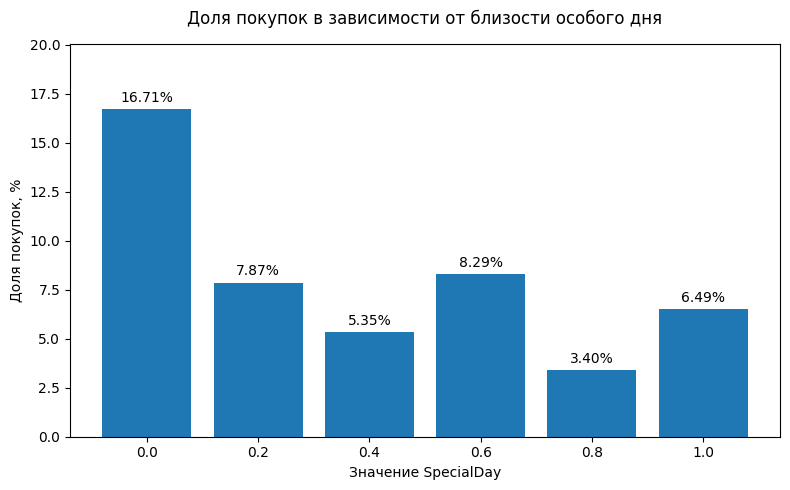

In [43]:
figure, axes = plt.subplots(figsize=(8, 5))

bars = axes.bar(
    special_day_summary.index.astype(str),
    special_day_summary["purchase_rate"],
)

axes.set_title(
    "Доля покупок в зависимости от близости особого дня",
    pad=14,
)
axes.set_xlabel("Значение SpecialDay")
axes.set_ylabel("Доля покупок, %")
axes.set_ylim(
    0,
    special_day_summary["purchase_rate"].max() * 1.2,
)

axes.bar_label(
    bars,
    labels=[
        f"{purchase_rate:.2f}%"
        for purchase_rate in special_day_summary["purchase_rate"]
    ],
    padding=3,
)

plt.tight_layout()
plt.show()

In [44]:
special_day_correlation, hypothesis_p_value = spearmanr(
    df["SpecialDay"],
    df["Revenue"].astype(int),
    alternative="greater",
)

_, reverse_p_value = spearmanr(
    df["SpecialDay"],
    df["Revenue"].astype(int),
    alternative="less",
)

print(
    "Корреляция Спирмена: "
    f"{special_day_correlation:.3f}"
)
print(
    "p-value для положительной связи: "
    f"{hypothesis_p_value:.3e}"
)
print(
    "p-value для отрицательной связи: "
    f"{reverse_p_value:.3e}"
)

Корреляция Спирмена: -0.088
p-value для положительной связи: 1.000e+00
p-value для отрицательной связи: 7.250e-23


In [45]:
is_near_special_day = df["SpecialDay"] > 0

special_day_binary_summary = (
    df.assign(is_near_special_day=is_near_special_day)
    .groupby("is_near_special_day")["Revenue"]
    .agg(
        session_count="size",
        purchase_count="sum",
        purchase_rate="mean",
    )
)

special_day_binary_summary["purchase_rate"] *= 100

special_day_binary_summary.index = (
    special_day_binary_summary.index.map(
        {
            False: "SpecialDay = 0",
            True: "SpecialDay > 0",
        }
    )
)

special_day_binary_summary.round(2)

,session_count,purchase_count,purchase_rate
is_near_special_day,,,
SpecialDay = 0,10956,1831,16.71
SpecialDay > 0,1249,77,6.16


In [46]:
near_special_day_purchase_count = int(
    special_day_binary_summary.loc[
        "SpecialDay > 0",
        "purchase_count",
    ]
)
near_special_day_session_count = int(
    special_day_binary_summary.loc[
        "SpecialDay > 0",
        "session_count",
    ]
)

regular_day_purchase_count = int(
    special_day_binary_summary.loc[
        "SpecialDay = 0",
        "purchase_count",
    ]
)
regular_day_session_count = int(
    special_day_binary_summary.loc[
        "SpecialDay = 0",
        "session_count",
    ]
)

z_statistic, p_value = proportions_ztest(
    count=[
        near_special_day_purchase_count,
        regular_day_purchase_count,
    ],
    nobs=[
        near_special_day_session_count,
        regular_day_session_count,
    ],
    alternative="smaller",
)

near_special_day_rate = (
    near_special_day_purchase_count
    / near_special_day_session_count
)
regular_day_rate = (
    regular_day_purchase_count
    / regular_day_session_count
)

print(f"Z-статистика: {z_statistic:.3f}")
print(f"p-value: {p_value:.3e}")
print(
    "Разница долей: "
    f"{(near_special_day_rate - regular_day_rate) * 100:.2f} п.п."
)

Z-статистика: -9.725
p-value: 1.183e-22
Разница долей: -10.55 п.п.


Доля покупок не увеличивается с ростом `SpecialDay`. При `SpecialDay = 0` она составила 16,71%, а при `SpecialDay > 0` - 6,16%.

Корреляция Спирмена равна −0,088. Положительная связь не подтвердилась (`p-value = 1`), а дополнительная проверка выявила слабую статистически значимую связь в обратном направлении (`p-value < 0,001`).

**Гипотеза 6 не подтверждается:** в этих данных близость особого дня связана с более низкой долей покупок.

### Итоги EDA и решения для дальнейшей работы

После удаления дубликатов осталось 12 205 наблюдений. Пропусков нет, нулевые значения имеют содержательный смысл.

Покупкой завершились 15,63% сессий, поэтому при разделении данных используем стратификацию, а основной метрикой сравнения моделей выбираем PR-AUC.

Экстремальные значения сохраняются: явных ошибок в них не обнаружено. Влияние логарифмического преобразования асимметричных признаков проверим отдельно.

Категориальные признаки закодируем с помощью One-Hot Encoding. Сильно коррелирующие признаки заранее удалять не будем.

Из-за сильной связи `PageValues` с целевой переменной отдельно сравним качество модели с этим признаком и без него.

## Гипотезы о моделировании

7. Логарифмическое преобразование правосторонне асимметричных признаков улучшит качество логистической регрессии.

8. Балансировка классов повысит recall покупок, но может снизить precision.

9. Случайный лес покажет более высокое качество, чем логистическая регрессия и одиночное дерево решений.

## Подготовка данных и разделение выборки

Данные разделяются на обучающую и тестовую выборки в соотношении 80/20 со стратификацией.

In [47]:
RANDOM_STATE = 42
TEST_SIZE = 0.20

X = df.drop(columns="Revenue")
y = df["Revenue"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

In [48]:
split_summary = pd.DataFrame(
    {
        "Количество наблюдений": [
            len(X_train),
            len(X_test),
        ],
        "Количество покупок": [
            y_train.sum(),
            y_test.sum(),
        ],
        "Доля покупок, %": [
            y_train.mean() * 100,
            y_test.mean() * 100,
        ],
    },
    index=[
        "Обучающая выборка",
        "Тестовая выборка",
    ],
)

split_summary.round(2)

,Количество наблюдений,Количество покупок,"Доля покупок, %"
Обучающая выборка,9764,1526,15.63
Тестовая выборка,2441,382,15.65


### Разделение признаков по типам

`Month`, `OperatingSystems`, `Browser`, `Region`, `TrafficType`, `VisitorType` и `Weekend` относятся к категориальным признакам.

`SpecialDay` остаётся числовым признаком, поскольку отражает степень близости к особому дню.

In [49]:
numeric_features = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay",
]

categorical_features = [
    "Month",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "VisitorType",
    "Weekend",
]

In [50]:
selected_features = numeric_features + categorical_features

missing_features = sorted(set(X_train.columns) - set(selected_features))
extra_features = sorted(set(selected_features) - set(X_train.columns))
duplicated_features = sorted(
    {
        feature
        for feature in selected_features
        if selected_features.count(feature) > 1
    }
)

feature_type_summary = pd.DataFrame(
    {
        "Группа": ["Числовые", "Категориальные", "Всего"],
        "Количество признаков": [
            len(numeric_features),
            len(categorical_features),
            len(selected_features),
        ],
    }
)

display(feature_type_summary)

print(f"Пропущенные признаки: {missing_features}")
print(f"Лишние признаки: {extra_features}")
print(f"Повторяющиеся признаки: {duplicated_features}")

,Группа,Количество признаков
0,Числовые,10
1,Категориальные,7
2,Всего,17


Пропущенные признаки: []
Лишние признаки: []
Повторяющиеся признаки: []


### Базовый пайплайн предобработки

Числовые признаки стандартизируются, категориальные - кодируются с помощью One-Hot Encoding.

Предобработка выполняется внутри пайплайна. Неизвестные категории игнорируются с помощью `handle_unknown="ignore"`.

In [51]:
numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore"),
        ),
    ]
)

baseline_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_features,
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features,
        ),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

In [52]:
baseline_logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", baseline_preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

baseline_logistic_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Administrative',
                                                   'Administrative_Duration',
                                                   'Informational',
                                                   'Informational_Duration',
                                                   'ProductRelated',
                                                   'ProductRelated_Duration',
                                                   'BounceRates', 'ExitRates',
                                                   'PageValues',
                                                   'SpecialDay']),
                                                 ('categorical',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Month', 'OperatingSystems',
                                                   'Browser', 'Region',
                                                   'TrafficType', 'VisitorType',
                                                   'Weekend'])],
                                   verbose_feature_names_out=False)),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

### Настройка кросс-валидации и метрик

Для оценки используется стратифицированная кросс-валидация на пяти разбиениях.

Основная метрика - PR-AUC. Accuracy используется как дополнительная метрика. Также рассчитываются ROC-AUC, precision, recall и F1.

Результаты сравниваются с наивной моделью, которая не использует признаки

In [53]:
N_SPLITS = 5

cross_validation = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

scoring_metrics = {
    "accuracy": "accuracy",
    "precision": make_scorer(
        precision_score,
        zero_division=0,
    ),
    "recall": make_scorer(
        recall_score,
        zero_division=0,
    ),
    "f1": make_scorer(
        f1_score,
        zero_division=0,
    ),
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
}

metric_names = {
    "accuracy": "Accuracy",
    "precision": "Precision",
    "recall": "Recall",
    "f1": "F1",
    "roc_auc": "ROC-AUC",
    "pr_auc": "PR-AUC",
}

In [54]:
def evaluate_models(
    models_to_evaluate: dict[str, BaseEstimator],
    group_column: str,
) -> pd.DataFrame:
    """Оценить модели на общей схеме кросс-валидации."""
    evaluation_rows = []

    for model_name, model in models_to_evaluate.items():
        cross_validation_results = cross_validate(
            estimator=model,
            X=X_train,
            y=y_train,
            cv=cross_validation,
            scoring=scoring_metrics,
            return_train_score=True,
            n_jobs=-1,
            error_score="raise",
        )

        for metric_code, metric_name in metric_names.items():
            evaluation_rows.append(
                {
                    group_column: model_name,
                    "Метрика": metric_name,
                    "Обучение": cross_validation_results[
                        f"train_{metric_code}"
                    ].mean(),
                    "Валидация": cross_validation_results[
                        f"test_{metric_code}"
                    ].mean(),
                    "Стандартное отклонение": cross_validation_results[
                        f"test_{metric_code}"
                    ].std(),
                }
            )

    return pd.DataFrame(evaluation_rows)

In [55]:
models = {
    "Наивная модель": DummyClassifier(
        strategy="prior",
        random_state=RANDOM_STATE,
    ),
    "Логистическая регрессия": baseline_logistic_pipeline,
}

baseline_cv_results = evaluate_models(
    models_to_evaluate=models,
    group_column="Модель",
)

display(baseline_cv_results.round(3))

,Модель,Метрика,Обучение,Валидация,Стандартное отклонение
0,Наивная модель,Accuracy,0.844,0.844,0.000
1,Наивная модель,Precision,0.000,0.000,0.000
2,Наивная модель,Recall,0.000,0.000,0.000
3,Наивная модель,F1,0.000,0.000,0.000
4,Наивная модель,ROC-AUC,0.500,0.500,0.000
5,Наивная модель,PR-AUC,0.156,0.156,0.000
6,Логистическая регрессия,Accuracy,0.883,0.882,0.005
7,Логистическая регрессия,Precision,0.749,0.744,0.029
8,Логистическая регрессия,Recall,0.381,0.372,0.028
9,Логистическая регрессия,F1,0.505,0.496,0.028


Наивная модель получила accuracy 0,844, но не выявила ни одной покупки.

Логистическая регрессия показала PR-AUC 0,636 и ROC-AUC 0,889. Precision составил 0,744, recall - 0,372, поэтому модель пропускает большую часть покупок.

Разница между обучающими и валидационными метриками небольшая. Результаты логистической регрессии используются как базовый уровень для следующих экспериментов

### Проверка влияния логарифмического преобразования

К правосторонне асимметричным признакам применяется `log1p`, после чего они стандартизируются.

Этот вариант сравнивается с базовой предобработкой на тех же разбиениях кросс-валидации

In [56]:
logarithmic_features = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "PageValues",
]

regular_numeric_features = [
    "BounceRates",
    "ExitRates",
    "SpecialDay",
]

In [57]:
logarithmic_transformer = Pipeline(
    steps=[
        (
            "logarithm",
            FunctionTransformer(
                np.log1p,
                feature_names_out="one-to-one",
            ),
        ),
        ("scaler", StandardScaler()),
    ]
)

regular_numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
    ]
)

logarithmic_preprocessor = ColumnTransformer(
    transformers=[
        (
            "logarithmic_numeric",
            logarithmic_transformer,
            logarithmic_features,
        ),
        (
            "regular_numeric",
            regular_numeric_transformer,
            regular_numeric_features,
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features,
        ),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

In [58]:
logarithmic_logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", logarithmic_preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

In [59]:
preprocessing_models = {
    "Исходные числовые признаки": baseline_logistic_pipeline,
    "Логарифмическое преобразование": logarithmic_logistic_pipeline,
}

preprocessing_cv_results = evaluate_models(
    models_to_evaluate=preprocessing_models,
    group_column="Предобработка",
)

display(preprocessing_cv_results.round(3))

,Предобработка,Метрика,Обучение,Валидация,Стандартное отклонение
0,Исходные числовые признаки,Accuracy,0.883,0.882,0.005
1,Исходные числовые признаки,Precision,0.749,0.744,0.029
2,Исходные числовые признаки,Recall,0.381,0.372,0.028
3,Исходные числовые признаки,F1,0.505,0.496,0.028
4,Исходные числовые признаки,ROC-AUC,0.897,0.889,0.012
5,Исходные числовые признаки,PR-AUC,0.650,0.636,0.022
6,Логарифмическое преобразование,Accuracy,0.896,0.893,0.006
7,Логарифмическое преобразование,Precision,0.715,0.705,0.027
8,Логарифмическое преобразование,Recall,0.559,0.550,0.029
9,Логарифмическое преобразование,F1,0.628,0.617,0.023


Логарифмическое преобразование улучшило логистическую регрессию:

- PR-AUC вырос с 0,636 до 0,683;
- F1 - с 0,496 до 0,617;
- recall - с 0,372 до 0,550;
- precision снизился с 0,744 до 0,705.

Разница между обучающими и валидационными результатами остаётся небольшой.

**Гипотеза 7 подтверждается.** Логарифмическая предобработка сохраняется для следующих экспериментов с логистической регрессией.

### Проверка влияния балансировки классов

Сравниваются две логистические регрессии с одинаковой предобработкой: без балансировки и с `class_weight="balanced"`.

In [60]:
balanced_logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", logarithmic_preprocessor),
        (
            "model",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1000,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

balancing_models = {
    "Без балансировки": logarithmic_logistic_pipeline,
    "С балансировкой классов": balanced_logistic_pipeline,
}

balancing_cv_results = evaluate_models(
    models_to_evaluate=balancing_models,
    group_column="Балансировка",
)

display(balancing_cv_results.round(3))

,Балансировка,Метрика,Обучение,Валидация,Стандартное отклонение
0,Без балансировки,Accuracy,0.896,0.893,0.006
1,Без балансировки,Precision,0.715,0.705,0.027
2,Без балансировки,Recall,0.559,0.550,0.029
3,Без балансировки,F1,0.628,0.617,0.023
4,Без балансировки,ROC-AUC,0.919,0.912,0.008
5,Без балансировки,PR-AUC,0.697,0.683,0.020
6,С балансировкой классов,Accuracy,0.868,0.864,0.007
7,С балансировкой классов,Precision,0.553,0.546,0.017
8,С балансировкой классов,Recall,0.811,0.796,0.018
9,С балансировкой классов,F1,0.658,0.647,0.015


Балансировка изменила соотношение ошибок:

- recall вырос с 0,550 до 0,796;
- precision снизился с 0,705 до 0,546;
- F1 вырос с 0,617 до 0,647;
- PR-AUC снизился с 0,683 до 0,664.

Модель стала находить больше покупок, но чаще ошибочно предсказывать положительный класс

**Гипотеза 8 подтверждается.** Поскольку основной метрикой выбрана PR-AUC, для дальнейшего сравнения сохраняется вариант без балансировки.

### Сравнение алгоритмов классификации

Сравниваются логистическая регрессия, дерево решений и случайный лес.

Для логистической регрессии используется логарифмическая предобработка. Древовидные модели получают числовые признаки без масштабирования.

Основная метрика сравнения - PR-AUC.

In [61]:
tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            "passthrough",
            numeric_features,
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features,
        ),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

In [62]:
decision_tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        (
            "model",
            DecisionTreeClassifier(
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                random_state=RANDOM_STATE,
                n_jobs=1,
            ),
        ),
    ]
)

In [63]:
classification_models = {
    "Логистическая регрессия": logarithmic_logistic_pipeline,
    "Дерево решений": decision_tree_pipeline,
    "Случайный лес": random_forest_pipeline,
}

model_comparison_results = evaluate_models(
    models_to_evaluate=classification_models,
    group_column="Модель",
)

display(model_comparison_results.round(3))

,Модель,Метрика,Обучение,Валидация,Стандартное отклонение
0,Логистическая регрессия,Accuracy,0.896,0.893,0.006
1,Логистическая регрессия,Precision,0.715,0.705,0.027
2,Логистическая регрессия,Recall,0.559,0.550,0.029
3,Логистическая регрессия,F1,0.628,0.617,0.023
4,Логистическая регрессия,ROC-AUC,0.919,0.912,0.008
5,Логистическая регрессия,PR-AUC,0.697,0.683,0.020
6,Дерево решений,Accuracy,1.000,0.862,0.010
7,Дерево решений,Precision,1.000,0.558,0.034
8,Дерево решений,Recall,1.000,0.568,0.014
9,Дерево решений,F1,1.000,0.563,0.024


Случайный лес показал лучший PR-AUC - 0,741 против 0,683 у логистической регрессии и 0,385 у дерева решений.

Дерево решений сильно переобучилось: на обучающих данных все метрики равны 1,0, но качество на валидации заметно ниже.

Случайный лес также переобучается, но сохраняет лучшее валидационное качество. Для снижения переобучения подберём его гиперпараметры

**Гипотеза 9 подтверждается.** Случайный лес выбран для дальнейшей настройки.

### Подбор гиперпараметров случайного леса

Параметры случайного леса подбираются с помощью `RandomizedSearchCV`

Критерий выбора - средний PR-AUC на пяти разбиениях обучающей выборки. Тестовая выборка в подборе не используется

In [64]:
random_forest_parameter_distributions = {
    "model__n_estimators": [200, 300, 400, 500],
    "model__max_depth": [None, 8, 12, 16, 20],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 4, 8],
    "model__max_features": ["sqrt", "log2", 0.5],
    "model__class_weight": [
        None,
        "balanced",
        "balanced_subsample",
    ],
}

random_forest_search = RandomizedSearchCV(
    estimator=random_forest_pipeline,
    param_distributions=random_forest_parameter_distributions,
    n_iter=20,
    scoring="average_precision",
    cv=cross_validation,
    refit=True,
    return_train_score=True,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    error_score="raise",
)

random_forest_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   error_score='raise',
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('numeric',
                                                                               'passthrough',
                                                                               ['Administrative',
                                                                                'Administrative_Duration',
                                                                                'Informational',
                                                                                'Informational_Duration',
                                                                                'ProductRelated',
                                                                                'ProductRelated_Duration',
                                                                                'BounceRates',
                                                                                'ExitRates...
                   param_distributions={'model__class_weight': [None,
                                                                'balanced',
                                                                'balanced_subsample'],
                                        'model__max_depth': [None, 8, 12, 16,
                                                             20],
                                        'model__max_features': ['sqrt', 'log2',
                                                                0.5],
                                        'model__min_samples_leaf': [1, 2, 4, 8],
                                        'model__min_samples_split': [2, 5, 10,
                                                                     20],
                                        'model__n_estimators': [200, 300, 400,
                                                                500]},
                   random_state=42, return_train_score=True,
                   scoring='average_precision', verbose=1)

In [65]:
print(
    "Лучший средний PR-AUC: "
    f"{random_forest_search.best_score_:.3f}"
)
print("Лучшие параметры:")

for parameter_name, parameter_value in (
    random_forest_search.best_params_.items()
):
    print(f"{parameter_name}: {parameter_value}")

Лучший средний PR-AUC: 0.754
Лучшие параметры:
model__n_estimators: 500
model__min_samples_split: 10
model__min_samples_leaf: 8
model__max_features: 0.5
model__max_depth: 20
model__class_weight: None


In [66]:
random_forest_search_results = pd.DataFrame(
    random_forest_search.cv_results_
)

search_result_columns = [
    "rank_test_score",
    "mean_train_score",
    "mean_test_score",
    "std_test_score",
    "param_model__n_estimators",
    "param_model__max_depth",
    "param_model__min_samples_split",
    "param_model__min_samples_leaf",
    "param_model__max_features",
    "param_model__class_weight",
]

top_random_forest_results = (
    random_forest_search_results[
        search_result_columns
    ]
    .sort_values("rank_test_score")
    .head(10)
)

display(top_random_forest_results.round(3))

,rank_test_score,mean_train_score,mean_test_score,std_test_score,param_model__n_estimators,param_model__max_depth,param_model__min_samples_split,param_model__min_samples_leaf,param_model__max_features,param_model__class_weight
19,1,0.901,0.754,0.020,500,20,10,8,0.5,None
8,2,0.885,0.753,0.020,400,8,10,1,0.5,None
16,3,0.963,0.751,0.019,300,20,5,4,0.5,balanced_subsample
15,4,0.936,0.751,0.021,500,12,10,4,0.5,balanced
2,5,0.955,0.749,0.021,400,None,10,4,0.5,balanced
1,6,0.861,0.748,0.020,400,8,20,1,0.5,balanced
13,7,1.000,0.745,0.019,300,20,2,1,sqrt,None
11,8,1.000,0.745,0.017,400,None,2,1,0.5,None
12,9,0.992,0.745,0.021,300,16,5,2,0.5,balanced
0,10,0.912,0.744,0.022,200,20,20,2,log2,None


Лучший средний PR-AUC вырос с 0,741 до 0,754.

Выбранные параметры:

- 500 деревьев
- максимальная глубина — 20
- минимум 10 наблюдений для разделения узла
- минимум 8 наблюдений в листе
- `max_features=0.5`
- без балансировки классов

Несколько лучших конфигураций показали близкие результаты, поэтому найденные параметры - не единственный возможный хороший вариант.

### Оценка случайного леса после настройки

Настроенная модель сравнивается с исходным случайным лесом на тех же разбиениях кросс-валидации

In [67]:
tuned_random_forest_pipeline = (
    random_forest_search.best_estimator_
)

forest_models = {
    "Случайный лес без настройки": random_forest_pipeline,
    "Случайный лес после настройки": tuned_random_forest_pipeline,
}

forest_comparison_results = evaluate_models(
    models_to_evaluate=forest_models,
    group_column="Модель",
)

display(forest_comparison_results.round(3))

,Модель,Метрика,Обучение,Валидация,Стандартное отклонение
0,Случайный лес без настройки,Accuracy,1.000,0.903,0.003
1,Случайный лес без настройки,Precision,1.000,0.782,0.018
2,Случайный лес без настройки,Recall,1.000,0.525,0.014
3,Случайный лес без настройки,F1,1.000,0.628,0.012
4,Случайный лес без настройки,ROC-AUC,1.000,0.925,0.004
5,Случайный лес без настройки,PR-AUC,1.000,0.741,0.018
6,Случайный лес после настройки,Accuracy,0.939,0.904,0.003
7,Случайный лес после настройки,Precision,0.873,0.740,0.018
8,Случайный лес после настройки,Recall,0.716,0.596,0.023
9,Случайный лес после настройки,F1,0.787,0.659,0.012


После настройки:

- PR-AUC вырос с 0,741 до 0,754
- recall с 0,525 до 0,596
- F1 с 0,628 до 0,659
- precision снизился с 0,782 до 0,740

Обучающий PR-AUC снизился с 1,000 до 0,901, поэтому переобучение стало меньше, хотя полностью не исчезло.

Настроенный случайный лес выбран для дальнейших проверок.

### Проверка модели без `PageValues`

Сравнивается качество настроенного случайного леса с `PageValues` и без него. В обоих вариантах используются одинаковые гиперпараметры.

In [68]:
numeric_features_without_page_values = [
    feature
    for feature in numeric_features
    if feature != "PageValues"
]

tree_preprocessor_without_page_values = ColumnTransformer(
    transformers=[
        (
            "numeric",
            "passthrough",
            numeric_features_without_page_values,
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features,
        ),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

tuned_forest_without_page_values = clone(
    tuned_random_forest_pipeline
)

tuned_forest_without_page_values.set_params(
    preprocessor=tree_preprocessor_without_page_values
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric', 'passthrough',
                                                  ['Administrative',
                                                   'Administrative_Duration',
                                                   'Informational',
                                                   'Informational_Duration',
                                                   'ProductRelated',
                                                   'ProductRelated_Duration',
                                                   'BounceRates', 'ExitRates',
                                                   'SpecialDay']),
                                                 ('categorical',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Month', 'OperatingSystems',
                                                   'Browser', 'Region',
                                                   'TrafficType', 'VisitorType',
                                                   'Weekend'])],
                                   verbose_feature_names_out=False)),
                ('model',
                 RandomForestClassifier(max_depth=20, max_features=0.5,
                                        min_samples_leaf=8,
                                        min_samples_split=10, n_estimators=500,
                                        n_jobs=1, random_state=42))])

In [69]:
page_values_models = {
    "С PageValues": tuned_random_forest_pipeline,
    "Без PageValues": tuned_forest_without_page_values,
}

page_values_comparison = evaluate_models(
    models_to_evaluate=page_values_models,
    group_column="Состав признаков",
)

display(page_values_comparison.round(3))

,Состав признаков,Метрика,Обучение,Валидация,Стандартное отклонение
0,С PageValues,Accuracy,0.939,0.904,0.003
1,С PageValues,Precision,0.873,0.740,0.018
2,С PageValues,Recall,0.716,0.596,0.023
3,С PageValues,F1,0.787,0.659,0.012
4,С PageValues,ROC-AUC,0.978,0.932,0.004
5,С PageValues,PR-AUC,0.901,0.754,0.020
6,Без PageValues,Accuracy,0.879,0.846,0.003
7,Без PageValues,Precision,0.957,0.549,0.069
8,Без PageValues,Recall,0.238,0.085,0.014
9,Без PageValues,F1,0.381,0.147,0.023


Без `PageValues` качество резко снизилось:

- PR-AUC с 0,754 до 0,379
- recall с 0,596 до 0,085
- F1 с 0,659 до 0,147

Модель сильно зависит от `PageValues`. Это не доказывает утечку, но перед практическим использованием нужно проверить, когда и как рассчитывается этот признак.

Сравнение проведено с параметрами, подобранными для полного набора признаков, поэтому оно показывает чувствительность модели, а не максимально возможное качество отдельной модели без `PageValues`.

В итоговой модели признак сохраняется

### Отбор признаков

Для отбора используется `SelectFromModel`. На каждом разбиении сохраняются признаки с важностью не ниже средней.

Отбор выполняется внутри пайплайна. Модель с отбором сравнивается с настроенным случайным лесом на всех признаках

In [70]:
tuned_random_forest_model = clone(
    tuned_random_forest_pipeline.named_steps["model"]
)

feature_selection_pipeline = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        (
            "feature_selector",
            SelectFromModel(
                estimator=clone(tuned_random_forest_model),
                threshold="mean",
            ),
        ),
        (
            "model",
            clone(tuned_random_forest_model),
        ),
    ]
)

In [71]:
feature_selection_models = {
    "Все признаки": tuned_random_forest_pipeline,
    "Отбор признаков": feature_selection_pipeline,
}

feature_selection_results = evaluate_models(
    models_to_evaluate=feature_selection_models,
    group_column="Набор признаков",
)

display(feature_selection_results.round(3))

,Набор признаков,Метрика,Обучение,Валидация,Стандартное отклонение
0,Все признаки,Accuracy,0.939,0.904,0.003
1,Все признаки,Precision,0.873,0.740,0.018
2,Все признаки,Recall,0.716,0.596,0.023
3,Все признаки,F1,0.787,0.659,0.012
4,Все признаки,ROC-AUC,0.978,0.932,0.004
5,Все признаки,PR-AUC,0.901,0.754,0.020
6,Отбор признаков,Accuracy,0.936,0.903,0.004
7,Отбор признаков,Precision,0.861,0.736,0.025
8,Отбор признаков,Recall,0.703,0.592,0.019
9,Отбор признаков,F1,0.774,0.656,0.012


In [72]:
fitted_feature_selection_pipeline = clone(
    feature_selection_pipeline
)

fitted_feature_selection_pipeline.fit(
    X_train,
    y_train,
)

transformed_feature_names = (
    fitted_feature_selection_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

selected_feature_mask = (
    fitted_feature_selection_pipeline
    .named_steps["feature_selector"]
    .get_support()
)

selected_feature_names = transformed_feature_names[
    selected_feature_mask
]

print(
    "Количество признаков после кодирования: "
    f"{len(transformed_feature_names)}"
)
print(
    "Количество выбранных признаков: "
    f"{len(selected_feature_names)}"
)

display(
    pd.DataFrame(
        {
            "Выбранный признак": selected_feature_names,
        }
    )
)

Количество признаков после кодирования: 74
Количество выбранных признаков: 9


,Выбранный признак
0,Administrative
1,Administrative_Duration
2,Informational_Duration
3,ProductRelated
4,ProductRelated_Duration
5,BounceRates
6,ExitRates
7,PageValues
8,Month_Nov


Отбор сократил количество признаков после кодирования с 74 до 9, но не улучшил модель:

- PR-AUC снизился с 0,754 до 0,745
- ROC-AUC с 0,932 до 0,922
- остальные метрики также немного снизились

Переобучение заметно не уменьшилось. Для финальной модели сохраняются все признаки.

## Финальная оценка модели

Настроенный случайный лес со всеми признаками обучается на полной обучающей выборке и оценивается на отложенной тестовой выборке

In [73]:
final_model = clone(tuned_random_forest_pipeline)

final_model.fit(X_train, y_train)

test_predictions = final_model.predict(X_test)
test_probabilities = final_model.predict_proba(X_test)[:, 1]

test_metrics = pd.DataFrame(
    {
        "Метрика": [
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "ROC-AUC",
            "PR-AUC",
        ],
        "Значение": [
            accuracy_score(y_test, test_predictions),
            precision_score(
                y_test,
                test_predictions,
                zero_division=0,
            ),
            recall_score(
                y_test,
                test_predictions,
                zero_division=0,
            ),
            f1_score(
                y_test,
                test_predictions,
                zero_division=0,
            ),
            roc_auc_score(y_test, test_probabilities),
            average_precision_score(
                y_test,
                test_probabilities,
            ),
        ],
    }
)

display(test_metrics.round(3))

,Метрика,Значение
0,Accuracy,0.905
1,Precision,0.732
2,Recall,0.623
3,F1,0.673
4,ROC-AUC,0.933
5,PR-AUC,0.754


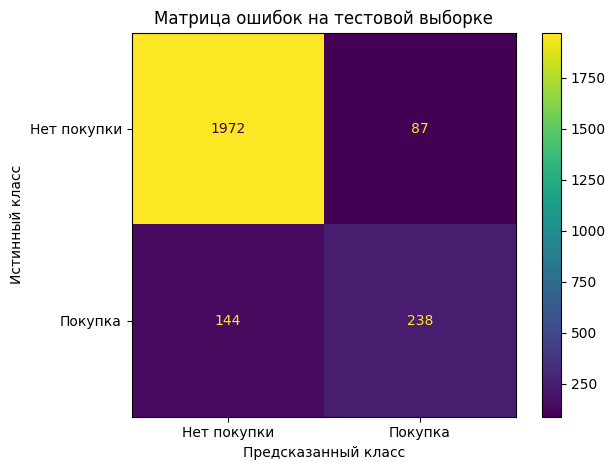

In [74]:
test_confusion_matrix = confusion_matrix(
    y_test,
    test_predictions,
)

confusion_matrix_display = ConfusionMatrixDisplay(
    confusion_matrix=test_confusion_matrix,
    display_labels=[
        "Нет покупки",
        "Покупка",
    ],
).plot()

confusion_matrix_display.ax_.set_title(
    "Матрица ошибок на тестовой выборке"
)
confusion_matrix_display.ax_.set_xlabel(
    "Предсказанный класс"
)
confusion_matrix_display.ax_.set_ylabel(
    "Истинный класс"
)

plt.tight_layout()
plt.show()

На тестовой выборке модель показала:

- PR-AUC - 0,754
- ROC-AUC - 0,933
- precision - 0,732
- recall - 0,623
- F1 - 0,673

Результаты практически совпали с кросс-валидацией. Модель правильно определила 238 из 382 покупок, пропустила 144 покупки и ошибочно предсказала покупку для 87 сессий.

Настроенный случайный лес со всеми признаками выбран как итоговая модель

### Важность признаков итоговой модели

In [75]:
final_feature_names = (
    final_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

final_feature_importances = (
    final_model
    .named_steps["model"]
    .feature_importances_
)

feature_importance_table = (
    pd.DataFrame(
        {
            "Признак": final_feature_names,
            "Важность": final_feature_importances,
        }
    )
    .sort_values("Важность", ascending=False)
    .reset_index(drop=True)
)

display(feature_importance_table.head(15).round(4))

,Признак,Важность
0,PageValues,0.5720
1,ExitRates,0.0739
2,ProductRelated_Duration,0.0614
3,BounceRates,0.0540
4,ProductRelated,0.0518
5,Administrative_Duration,0.0374
6,Month_Nov,0.0327
7,Administrative,0.0323
8,Informational_Duration,0.0137
9,Informational,0.0066


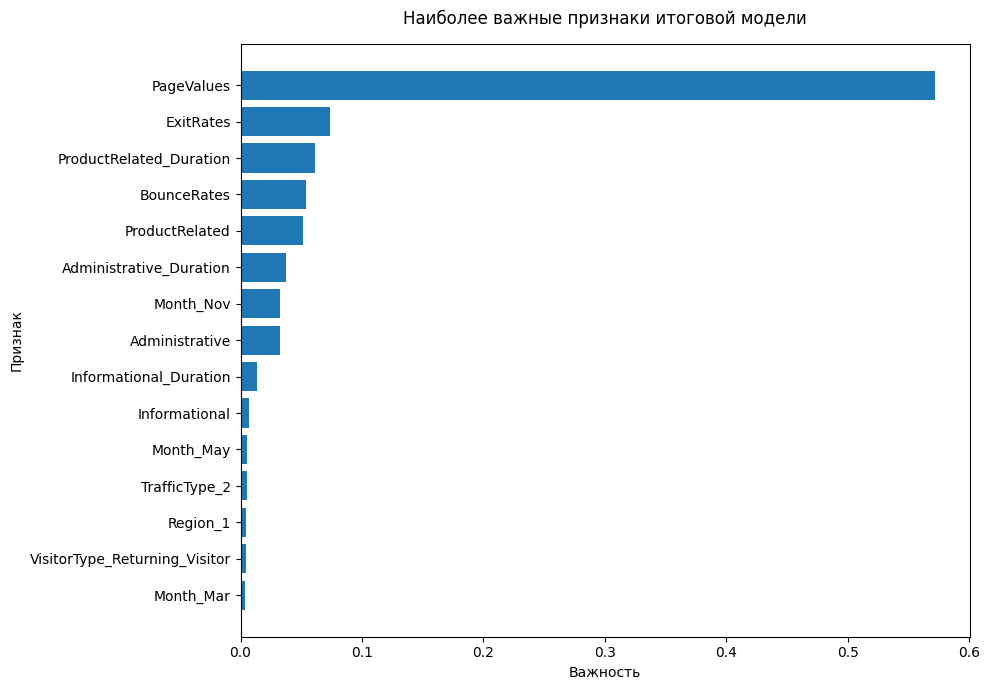

In [76]:
top_feature_importances = feature_importance_table.head(15).sort_values(
    "Важность",
    ascending=True,
)

figure, axes = plt.subplots(figsize=(10, 7))

axes.barh(
    top_feature_importances["Признак"],
    top_feature_importances["Важность"],
)

axes.set_title(
    "Наиболее важные признаки итоговой модели",
    pad=14,
)
axes.set_xlabel("Важность")
axes.set_ylabel("Признак")

plt.tight_layout()
plt.show()

Наиболее важный признак - `PageValues`, его важность составляет 0,572. Далее идут `ExitRates`, `ProductRelated_Duration`, `BounceRates` и `ProductRelated`.

Результат согласуется с отдельной проверкой: без `PageValues` PR-AUC снизился с 0,754 до 0,379.

Итоговая модель сильно зависит от этого признака. Перед практическим использованием нужно проверить, доступен ли `PageValues` в момент прогноза. Его высокая важность не доказывает утечку или причинное влияние.

## Общий итог

После удаления 125 полных дубликатов в данных осталось 12 205 сессий. Покупкой завершились 15,63% сессий, поэтому основной метрикой сравнения моделей была выбрана PR-AUC.

Данные разделены на обучающую и тестовую выборки со стратификацией. Предобработка, отбор признаков и обучение выполнялись внутри пайплайнов. Для сравнения моделей использовалась пятифолдовая кросс-валидация.

Логарифмическое преобразование улучшило PR-AUC логистической регрессии с 0,636 до 0,683. Балансировка повысила recall, но снизила precision и PR-AUC.

Лучший результат показал случайный лес. После подбора параметров его валидационный PR-AUC вырос с 0,741 до 0,754. Отбор признаков сократил их количество с 74 до 9, но немного ухудшил качество, поэтому в итоговой модели сохранены все признаки.

На тестовой выборке итоговая модель показала:

- PR-AUC - 0,754
- ROC-AUC - 0,933
- precision - 0,732
- recall - 0,623
- F1 - 0,673

Результаты почти совпали с кросс-валидацией.

Модель сильно зависит от `PageValues`: без него PR-AUC снизился до 0,379. Перед практическим использованием нужно проверить, доступен ли этот признак в момент прогноза

Итоговая модель - настроенный случайный лес со всеми признаками.

## Сводка результатов гипотез

### Гипотезы о данных

| № | Гипотеза | Результат | Итог |
|---:|---|---|---|
| 1 | В сессиях с покупкой просматривают больше товарных страниц. | Подтверждается | Медиана: 29 против 16, `p-value < 0,001`. |
| 2 | В сессиях с покупкой дольше просматривают товарные страницы. | Подтверждается | Медиана: 1109,91 против 526,00, `p-value < 0,001`. |
| 3 | В сессиях с покупкой ниже `BounceRates`. | Подтверждается | Медиана: 0 против 0,0039, `p-value < 0,001`. |
| 4 | При покупке чаще посещают административные страницы. | Подтверждается | 73,06% против 50,19%, `p-value < 0,001`. |
| 5 | Вернувшиеся посетители покупают чаще новых. | Не подтверждается | Доля покупок: 14,09% против 24,93% у новых посетителей. |
| 6 | Доля покупок растёт с увеличением `SpecialDay`. | Не подтверждается | При `SpecialDay = 0` доля покупок равна 16,71%, при `SpecialDay > 0` — 6,16%. |

### Гипотезы о моделировании

| № | Гипотеза | Результат | Итог |
|---:|---|---|---|
| 7 | Логарифмическое преобразование улучшит логистическую регрессию. | Подтверждается | PR-AUC вырос с 0,636 до 0,683. |
| 8 | Балансировка повысит recall, но снизит precision. | Подтверждается | Recall вырос с 0,550 до 0,796, precision снизился с 0,705 до 0,546. |
| 9 | Случайный лес превзойдёт логистическую регрессию и дерево решений. | Подтверждается | PR-AUC: 0,741 против 0,683 и 0,385. После настройки — 0,754. |

Подтвердились семь из девяти гипотез. Гипотезы о более высокой доле покупок среди вернувшихся посетителей и росте покупок при увеличении `SpecialDay` не подтвердились